<link rel="stylesheet" href="notebooks/styles.css">

<div class="title-wrap">
  <h1 class="title-main" style="font-weight: bold; font-size: 2.65rem; margin-bottom: 0.5rem;">
  Spatial Data Science Approaches to Wildfire Severity Modeling
</h1>
<h2 class="title-sub" style="font-style: italic; font-size: 1.8rem; margin-top: 0rem; margin-bottom: 0.2rem;">
  A GIS‑Driven, Tree‑Based Machine Learning Analysis of California Wildfires
</h2>
</div>

# Module 4: *Variable Selection*
##### Version Number: 4.0
---
### Contents  
> *Water Demand*
> *Water Supply*
> *Water Supply Indexes*
> *Fire Danger Indicators*
> *Social Variables*
> *Elevation*
> *WUI*
> *Ecological*
> *Land Cover*
> *Interactions*
> *Wind Slope*
> *Others*
> *Export File*
---
### Notes
- This module visualizes variables relationships with different wildfire severity categories. Based on the `Categorical` target, we explore how different weather features interact.
---
### Inputs
- `engineered_samples.csv` engineered and cleaned samples data with weather, fire, and grid data.
---
### Outputs 
---
### User Defined Dependencies

In [1]:
import os
import sys

# Allow import of custom modules from the parent directory
sys.path.append(os.path.abspath(os.path.join('..')))

from src.data_utils import *
from src.model_utils import *
from src.plot_utils import *

---
### Third Party Dependencies

In [2]:
# Core data tools
import pandas as pd
import numpy as np
from datetime import datetime
import json

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

# Set consistent plotting style
sns.set(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

---

In [3]:
def plot_all(df, target1, target2, target3, title):
    bar_group(df, target1,'Ignition')
    bar_group(df, target2,'Spread')
    bar_group(df, target3,'Damage')

### Loading Data

In [4]:
samples = pd.read_csv('../data/processed/engineered_samples.csv')

In [5]:
with open('feature_sets.json', 'r') as f:
    feature_sets = json.load(f)

---

## Split dataset temporarily for variable analysis

In [6]:
# Columns to drop for feature interaction analysis
text_columns = ['Sample_ID', 'Date', 'grid_id',
       'geometry', 'fire_count', 'total_fire_damage','acres','area_in_cali','maximum_x', 'minimum_y',
       'maximum_y', 'minimum_x','centroid_northing','centroid_easting','Target_Damage','Target_Ignition',
               'Target_Spread','Year','acres_per_day','damage_per_day','acres_burned_so_far','damage_so_far']

coded_columns = ['dominant_province_description','dominant_section_description','Season']

numerical_data = samples.drop(columns=text_columns + coded_columns)
detail_data = samples[text_columns]

target_ignition = samples['Target_Ignition']
target_spread = samples['Target_Spread']
target_damage = samples['Target_Damage']

## Scale numerical columns for easier side by side comparisons

In [7]:
scaler = MinMaxScaler()

# Scale main dataset
X_scaled = scaler.fit_transform(numerical_data)
X = pd.DataFrame(X_scaled, columns=numerical_data.columns, index=numerical_data.index)

## DIrect Water Demand Indicators

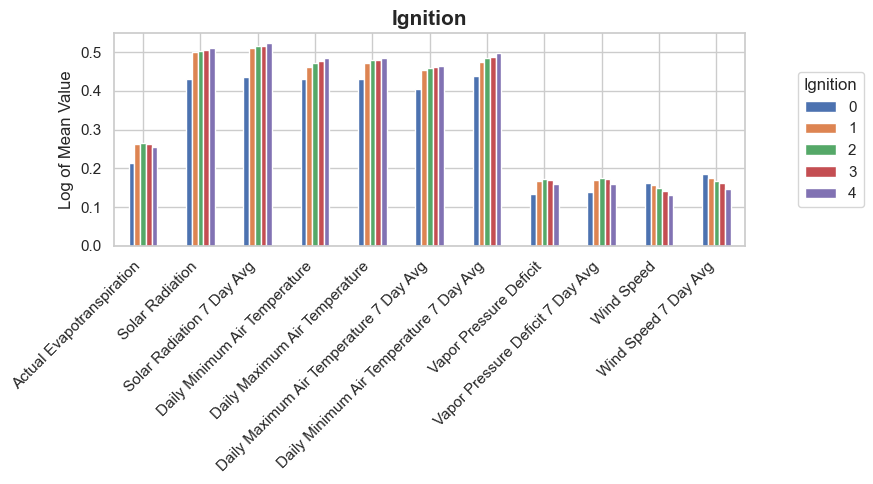

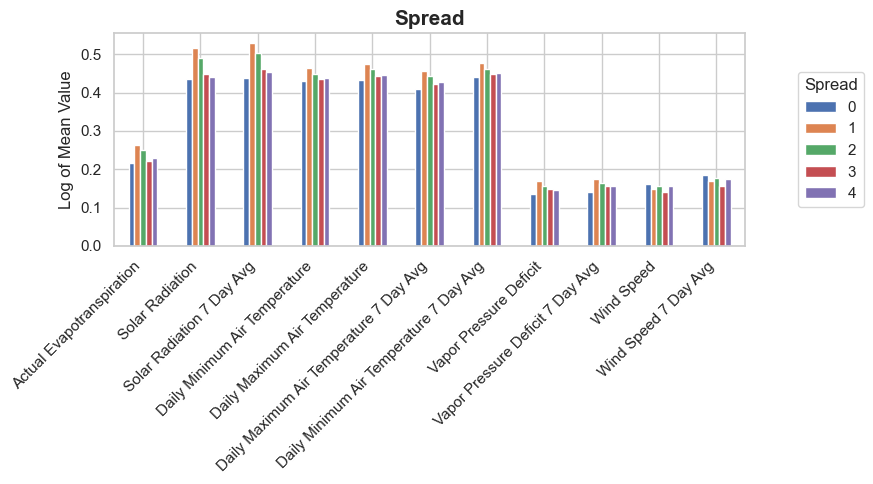

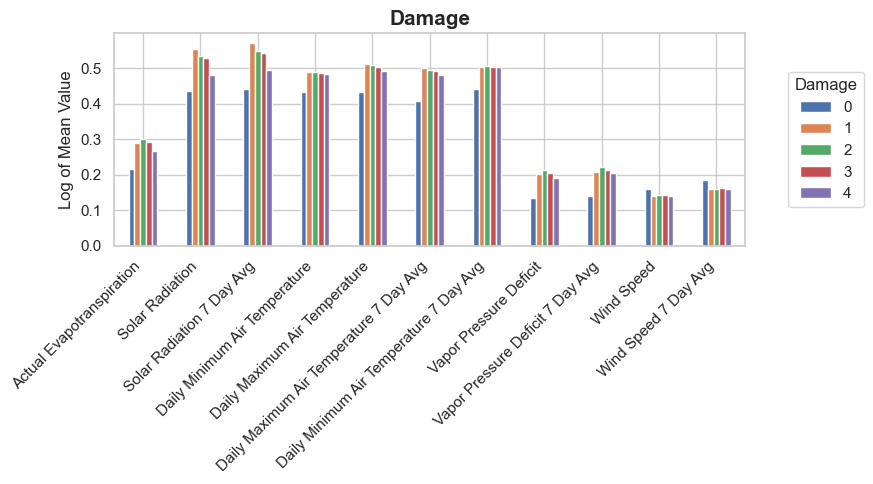

In [8]:
plot_all(X[feature_sets['Water Demand']], target_ignition, target_spread,target_damage, 'Water Demand')

---

## Water Supply Indicators

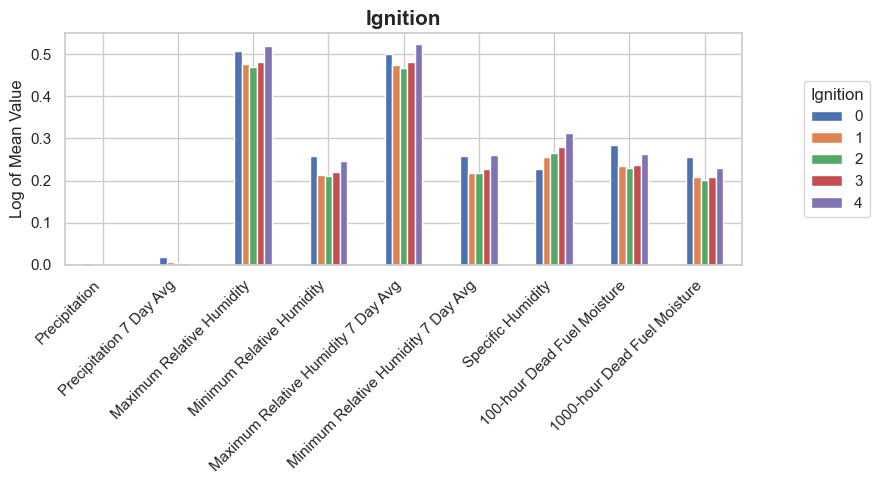

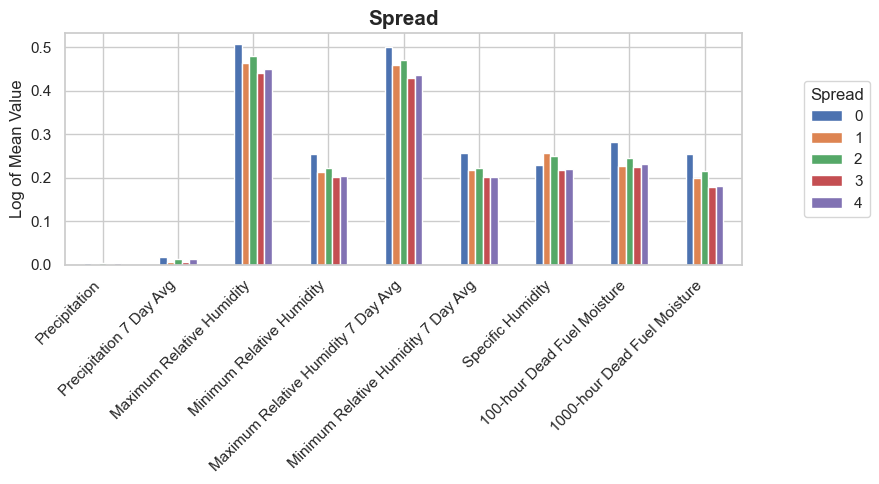

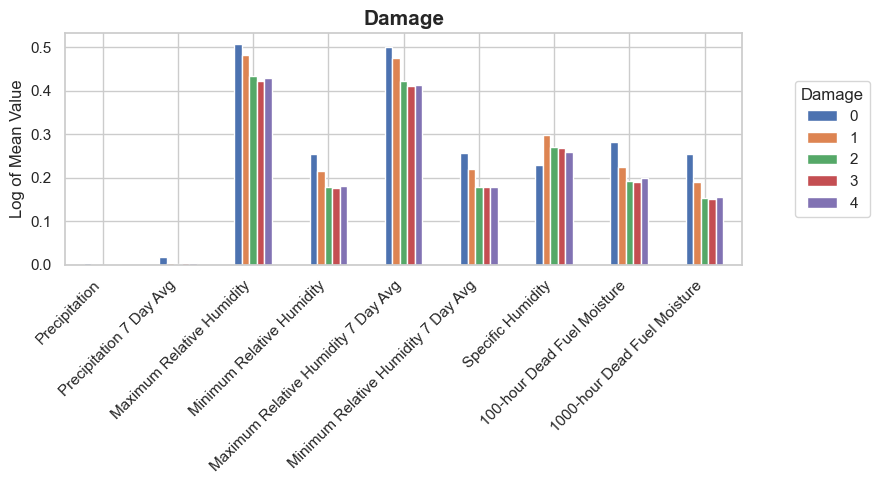

In [9]:
plot_all(X[feature_sets['Water Supply']], target_ignition, target_spread,target_damage,'Water Supply')

---

## Water Supply Indexes

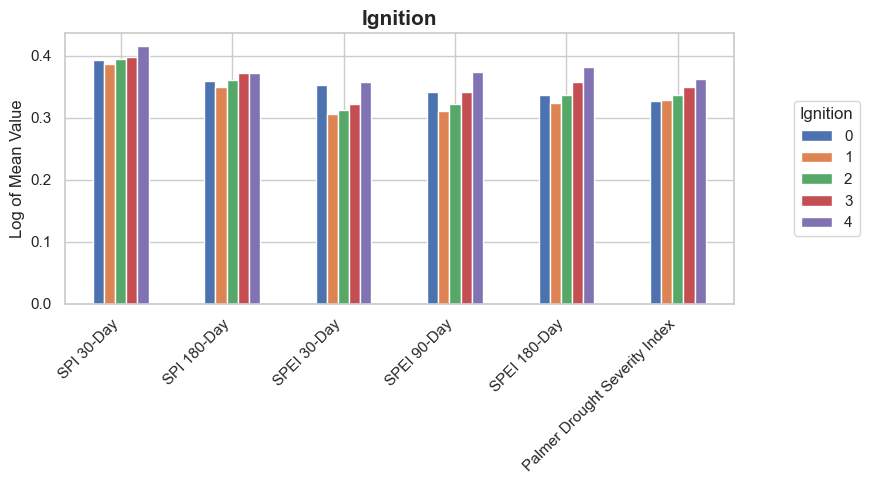

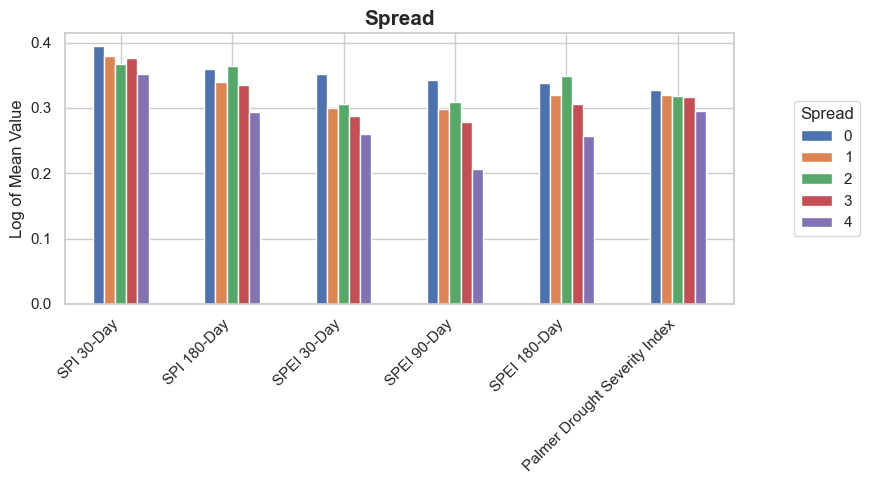

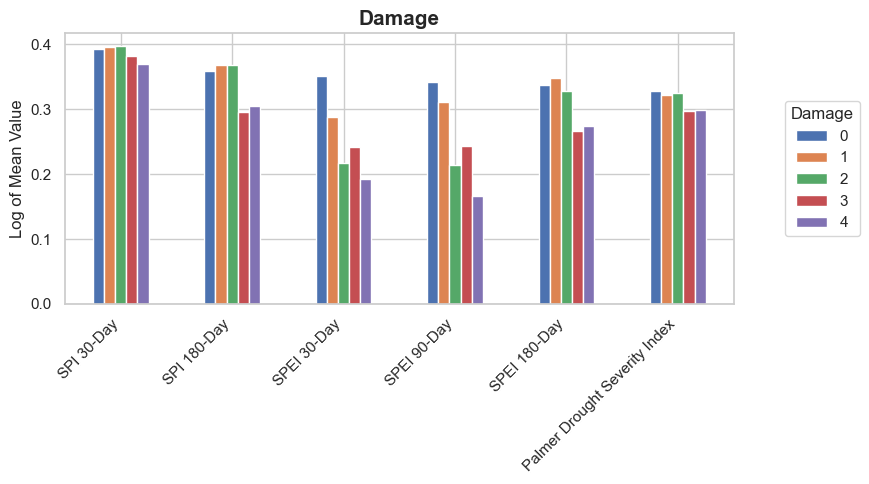

In [10]:
plot_all(X[feature_sets['Water Supply Indexes']], target_ignition, target_spread,target_damage,'Water Supply Indexes')

## Fire Danger

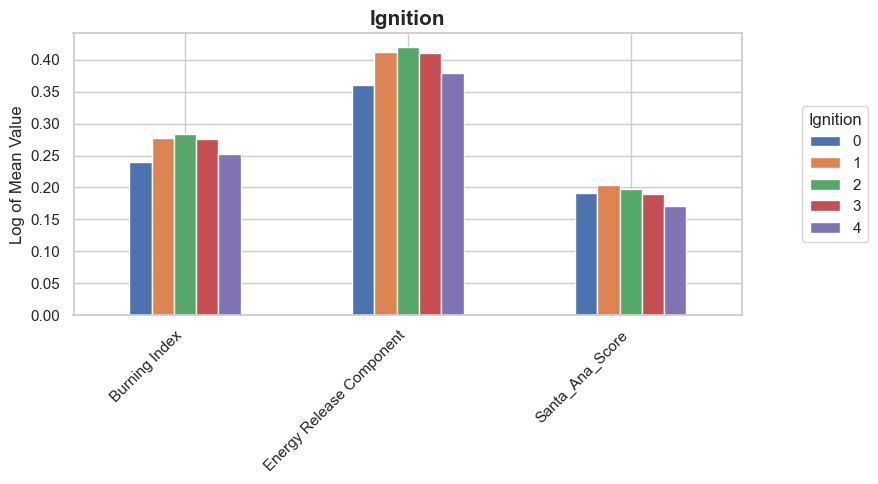

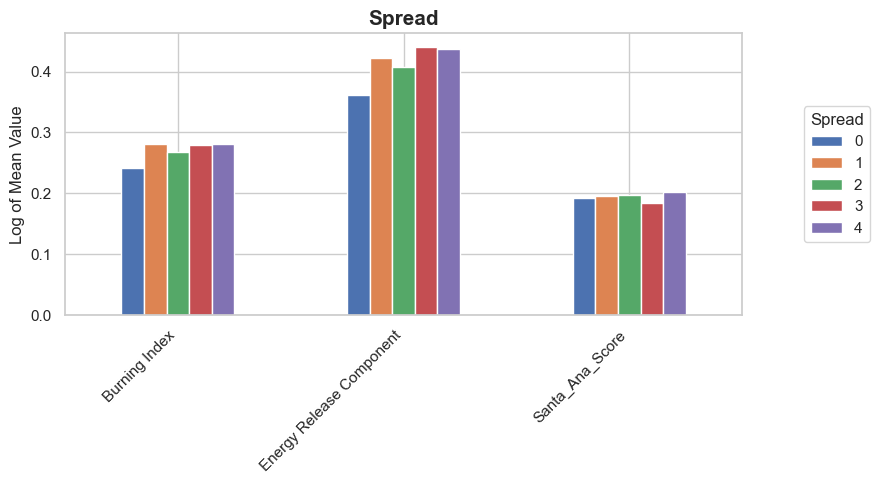

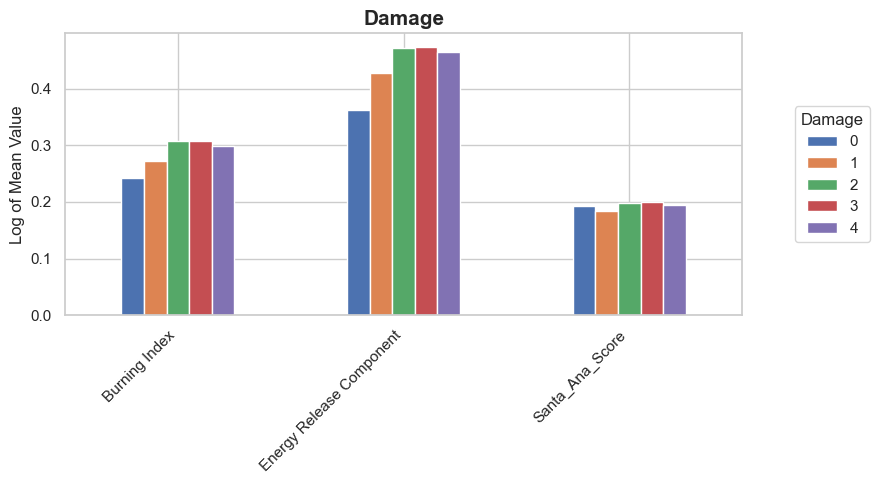

In [11]:
plot_all(X[feature_sets['Fire Danger']], target_ignition, target_spread,target_damage,'Fire Danger')

## Social Variables

In [12]:
social = ['total_housing', 'total_population',
       'housing_density', 'population_density', 'median_income']

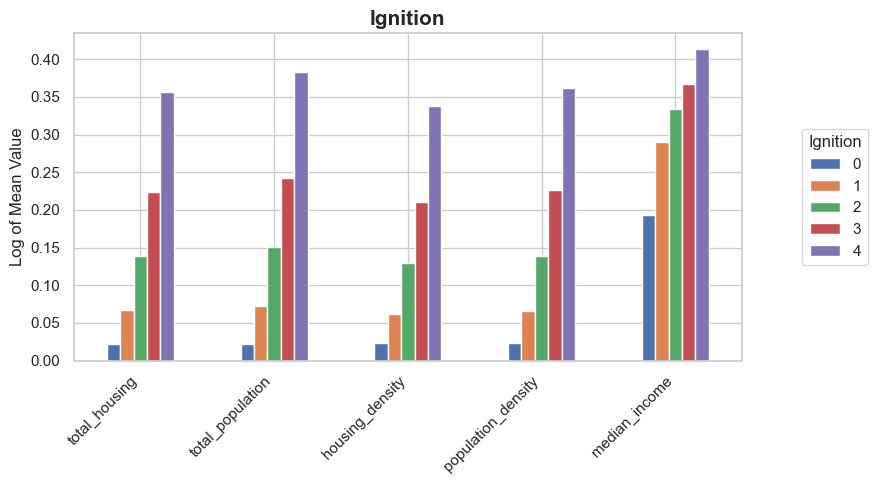

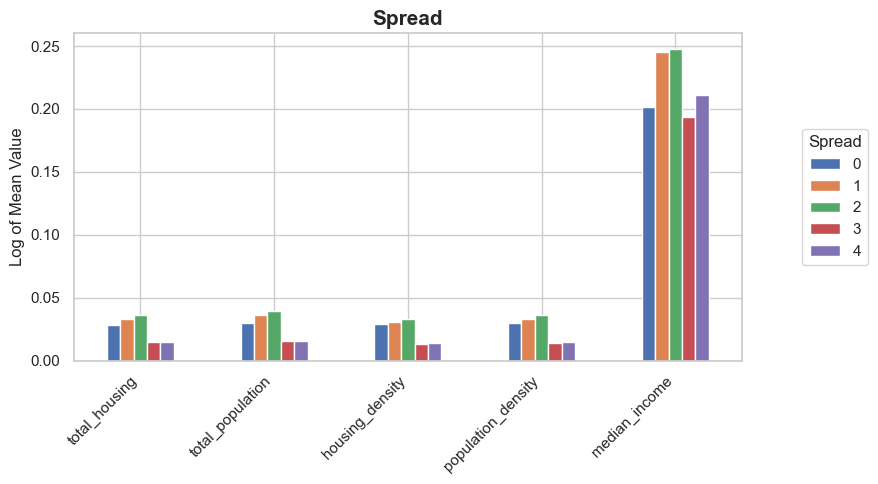

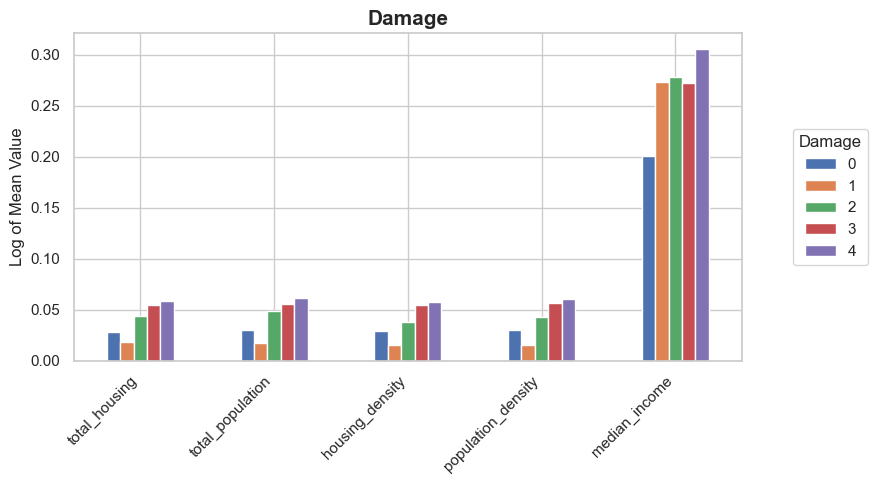

In [13]:
plot_all(X[feature_sets["Social"]], target_ignition, target_spread,target_damage,'Social')

## Elevation

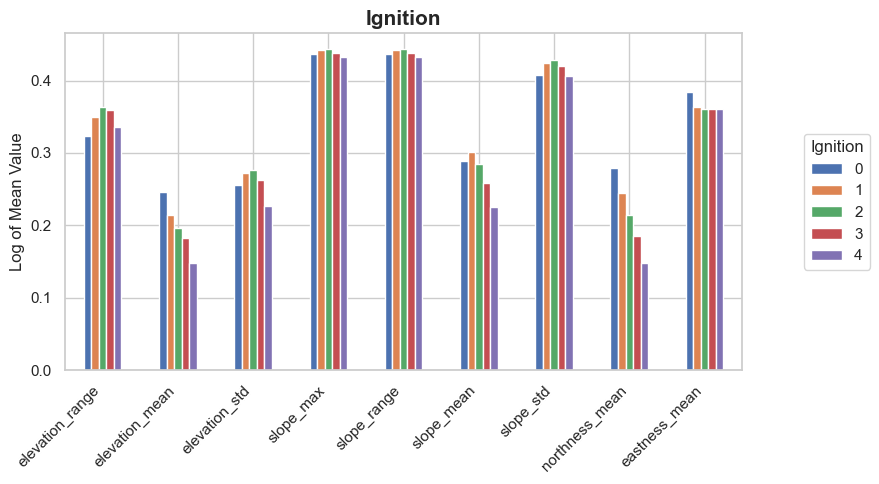

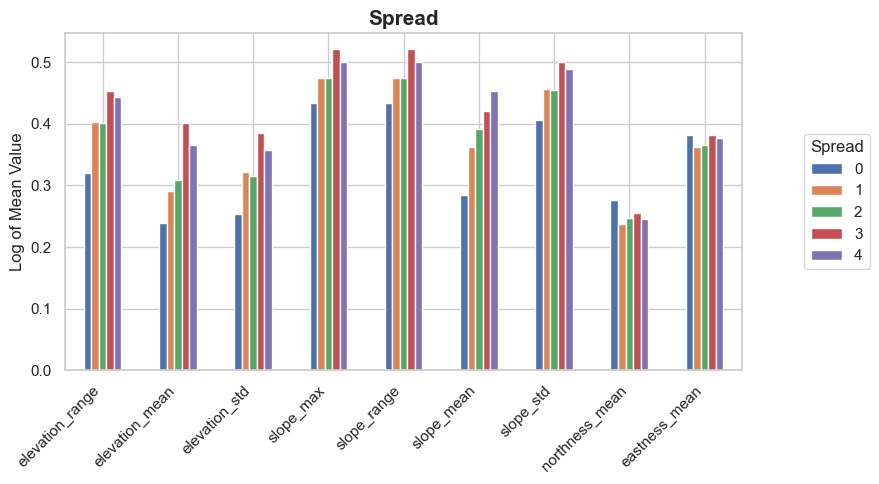

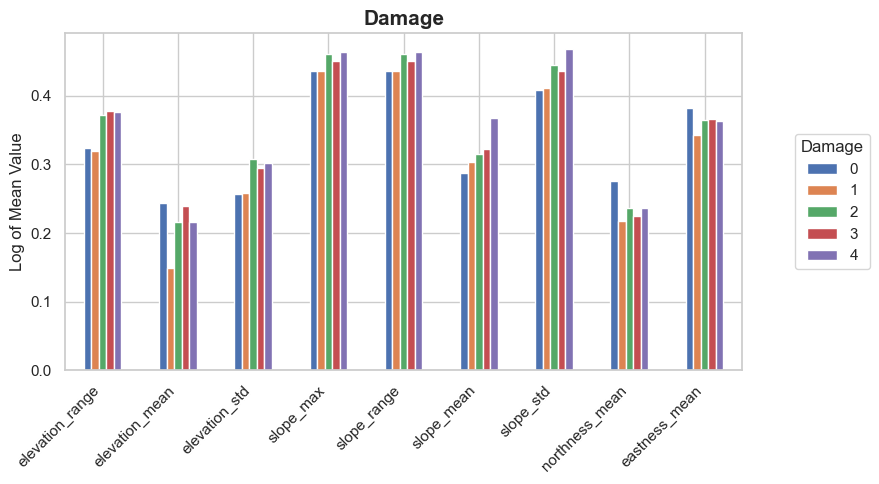

In [14]:
plot_all(X[feature_sets['Elevation']], target_ignition, target_spread,target_damage,'Elevation')

## WUI

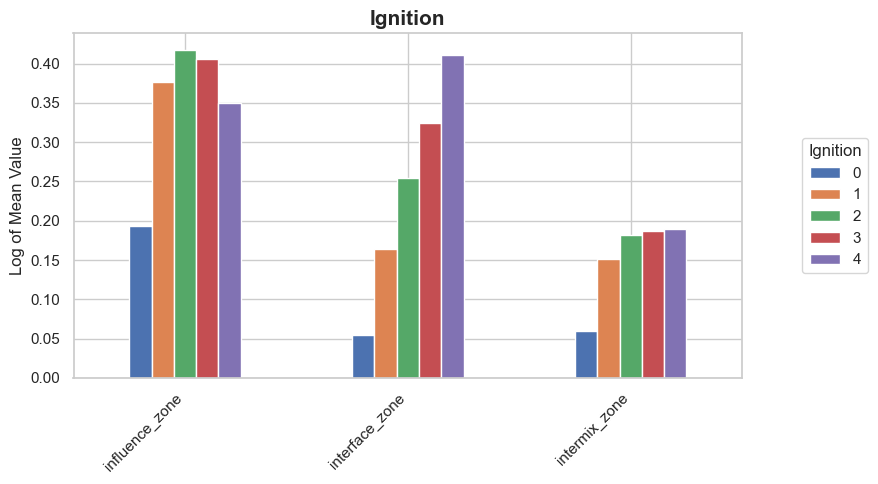

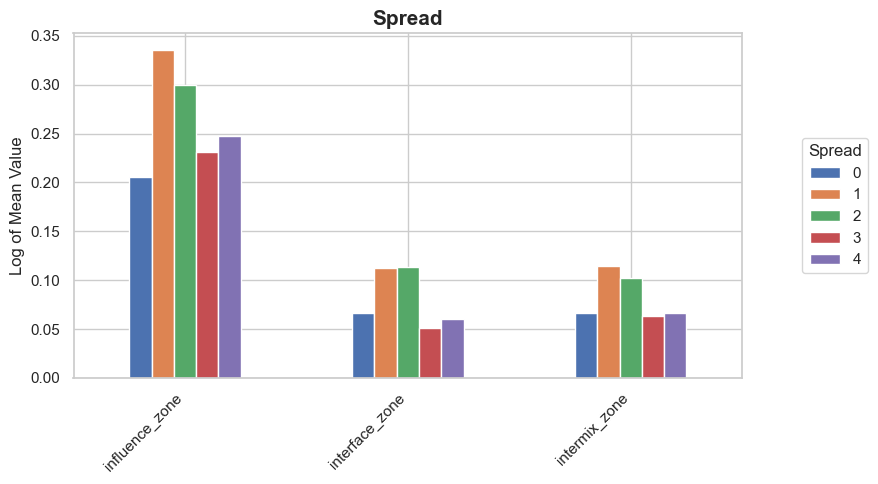

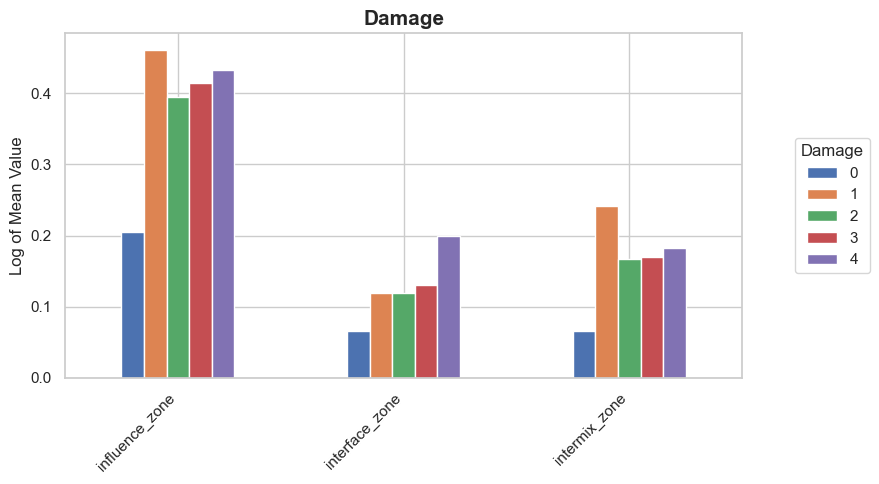

In [15]:
plot_all(X[feature_sets['WUI']], target_ignition, target_spread,target_damage,'WUI')

## Ecological

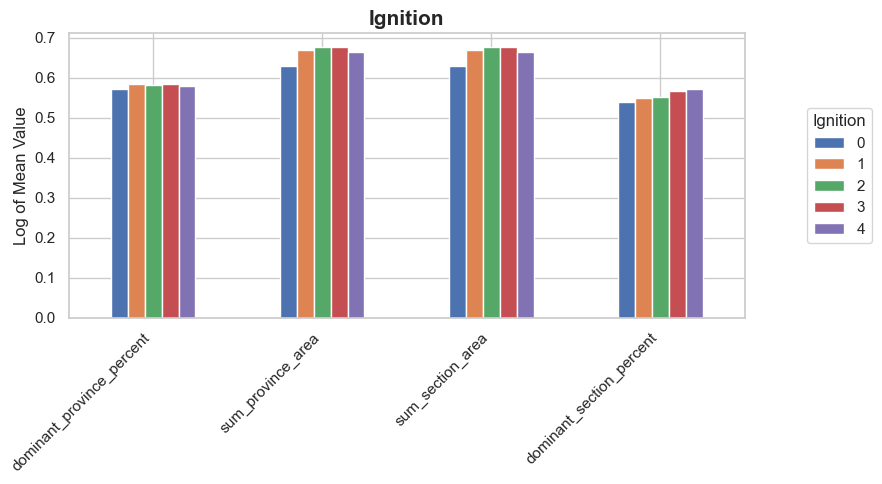

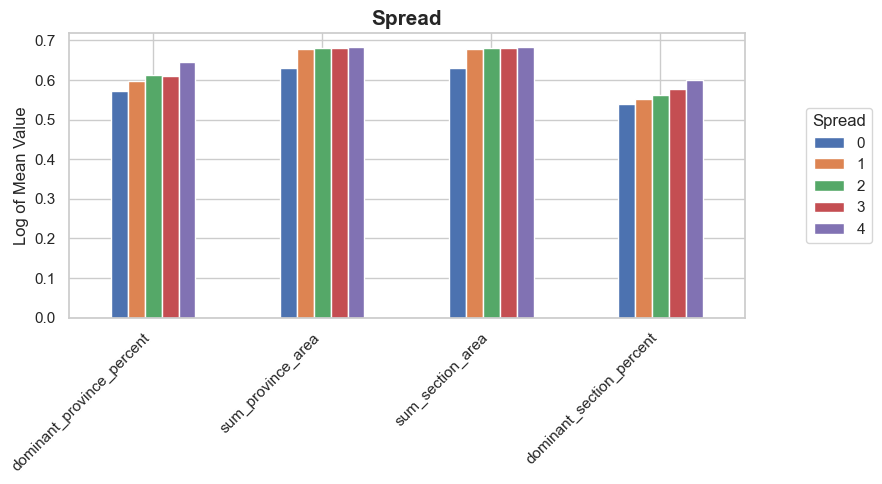

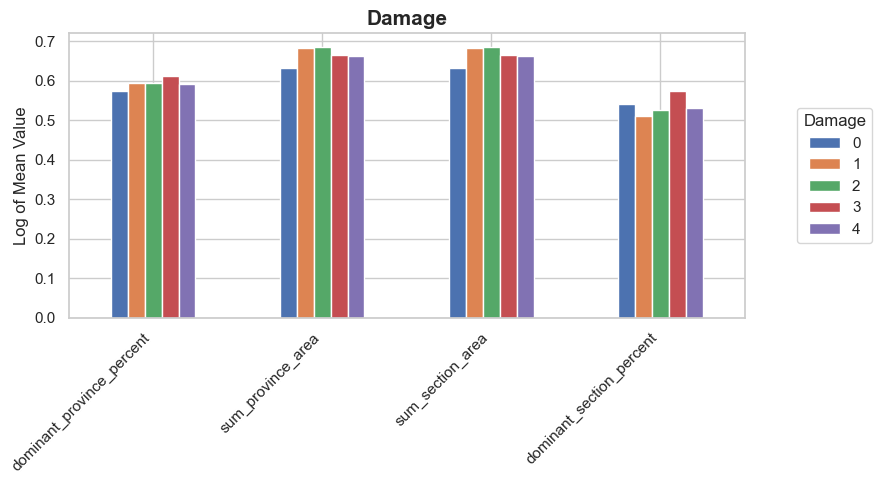

In [16]:
plot_all(X[feature_sets['Ecoregion']], target_ignition, target_spread,target_damage,'Ecological')

## Land Cover

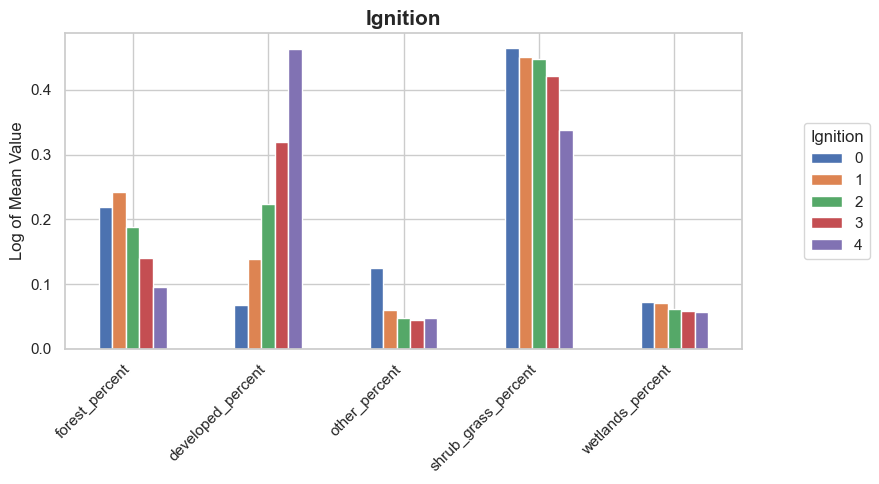

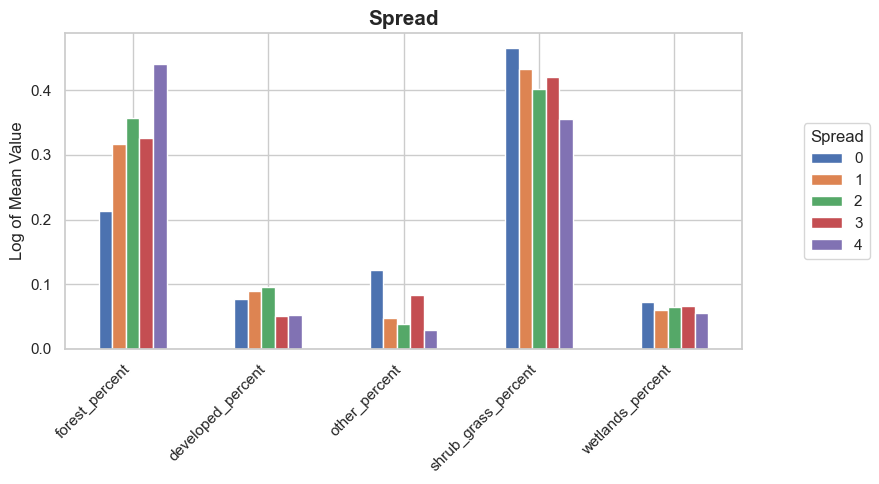

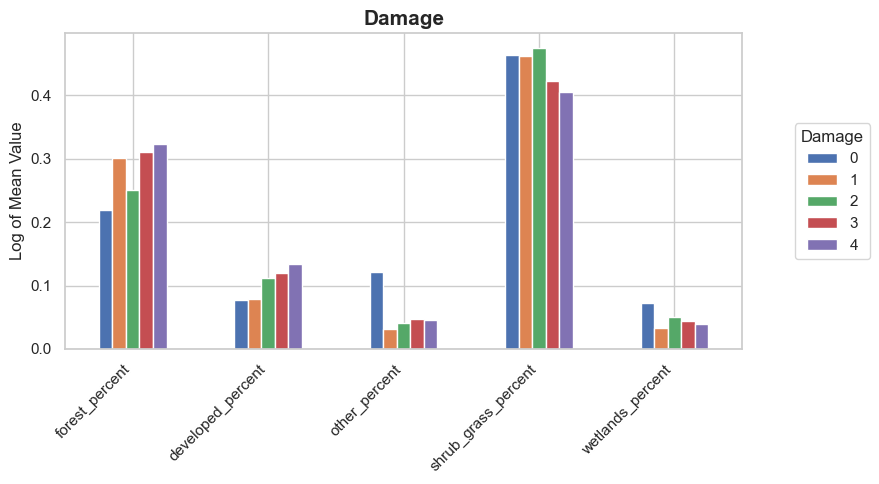

In [17]:
plot_all(X[feature_sets['Land Cover']], target_ignition, target_spread,target_damage,'Land Cover')

## Interactions

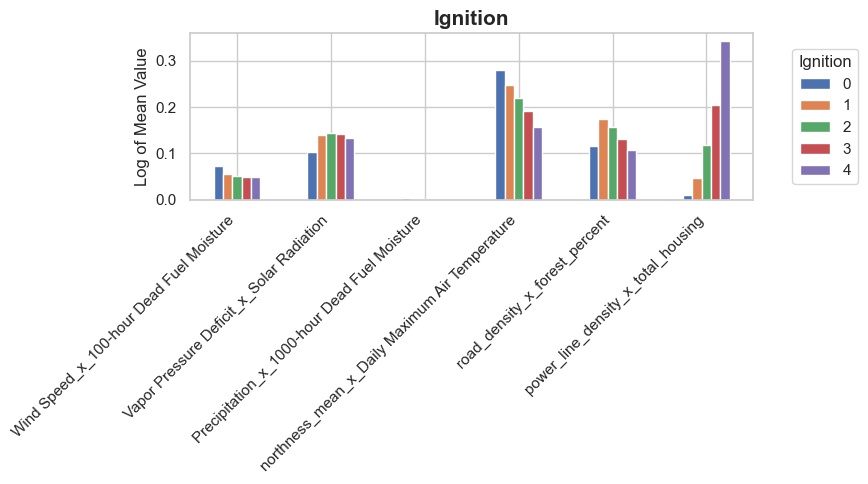

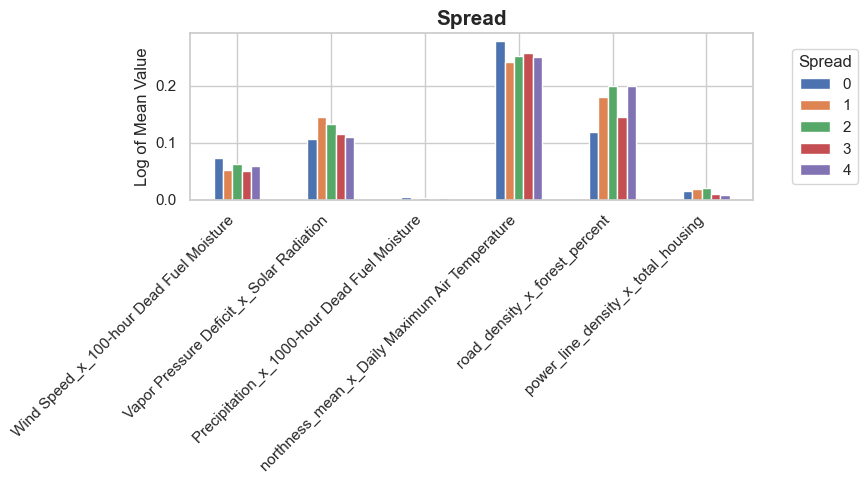

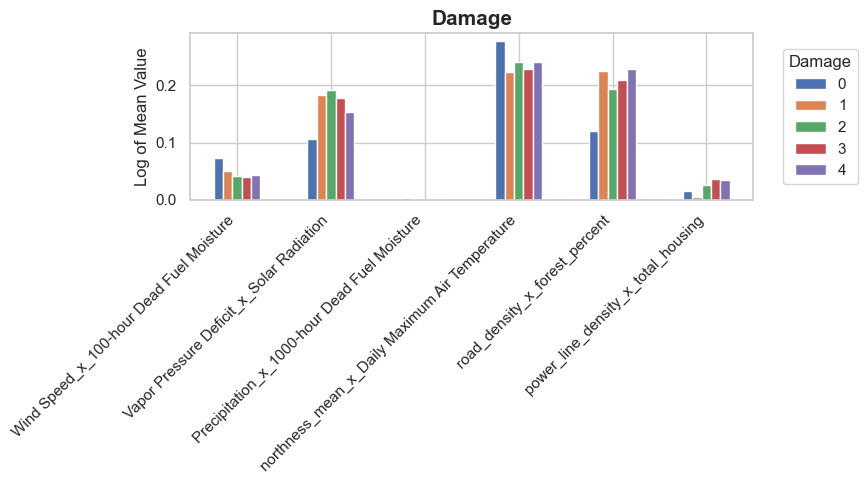

In [18]:
plot_all(X[feature_sets['Interactions']], target_ignition, target_spread,target_damage,'Interactions')

## Wind Slope Interaction

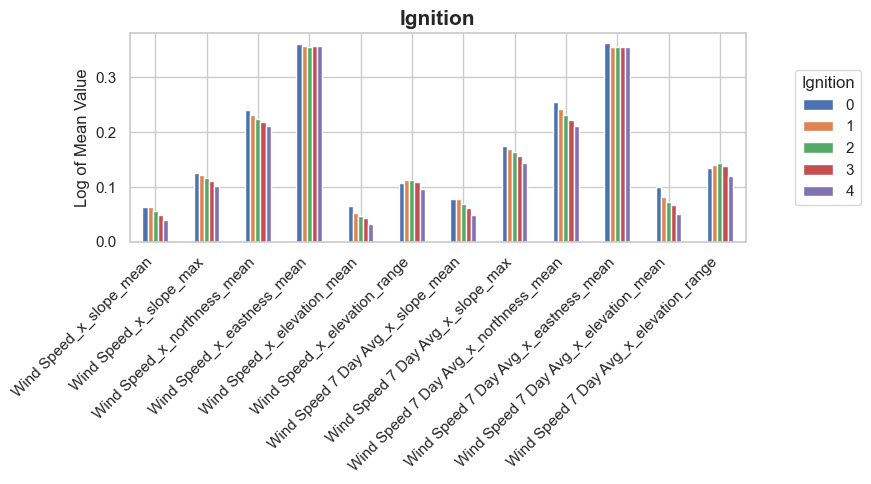

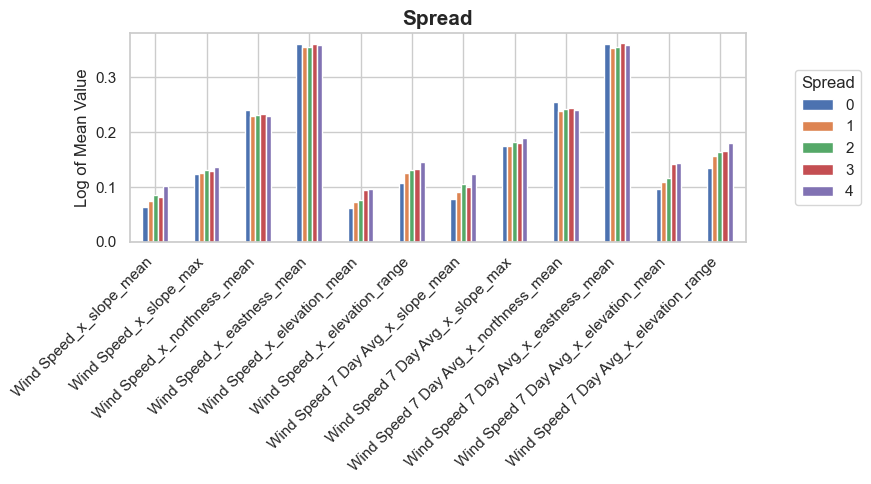

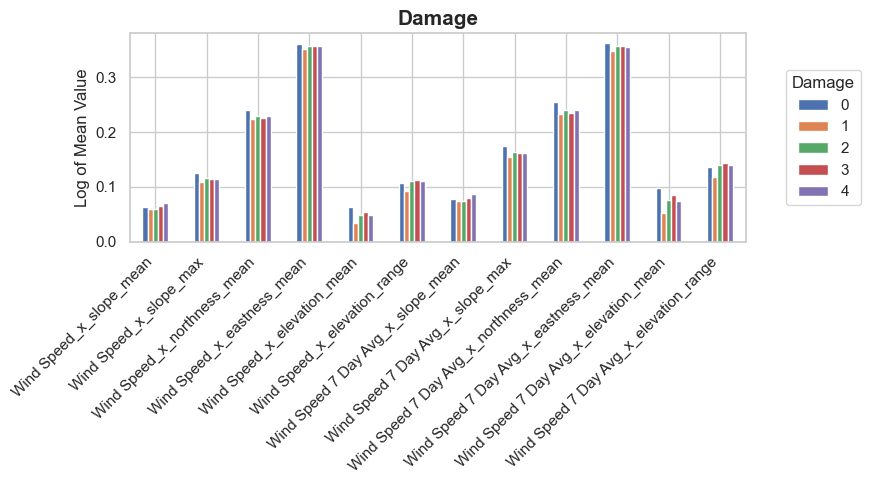

In [19]:
plot_all(X[feature_sets['Wind Slope']], target_ignition, target_spread,target_damage,'Wind Slope Interactions')

## Others

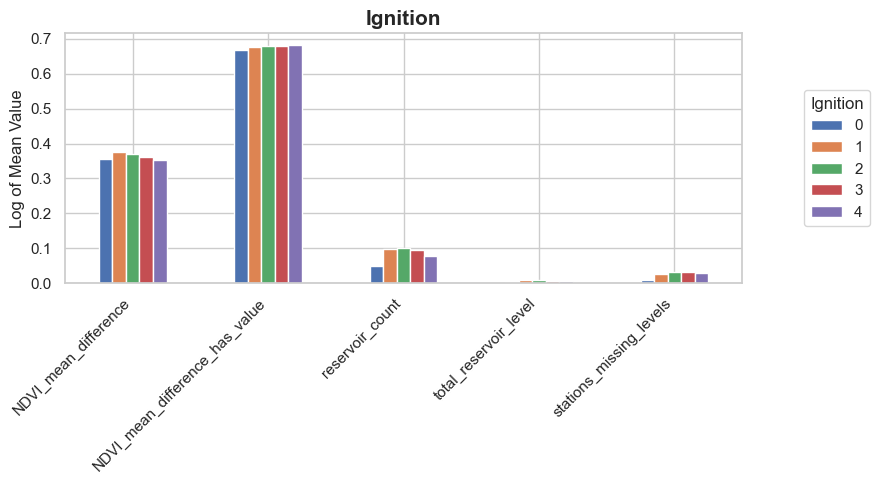

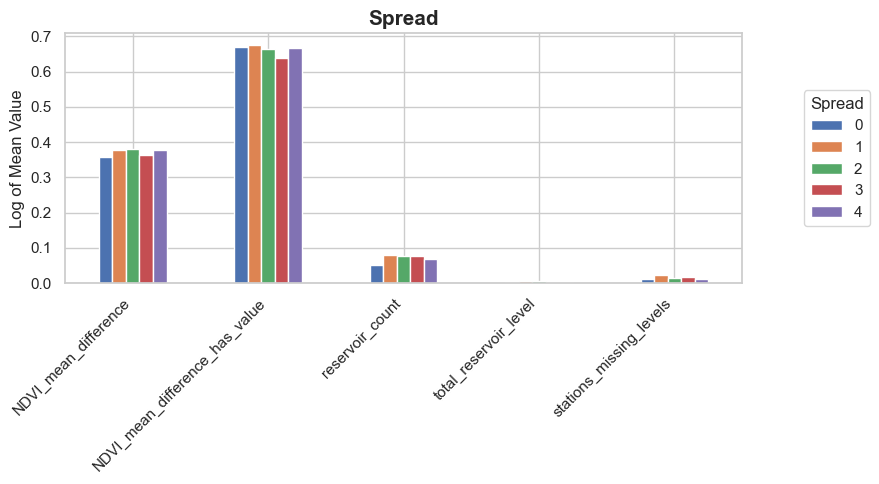

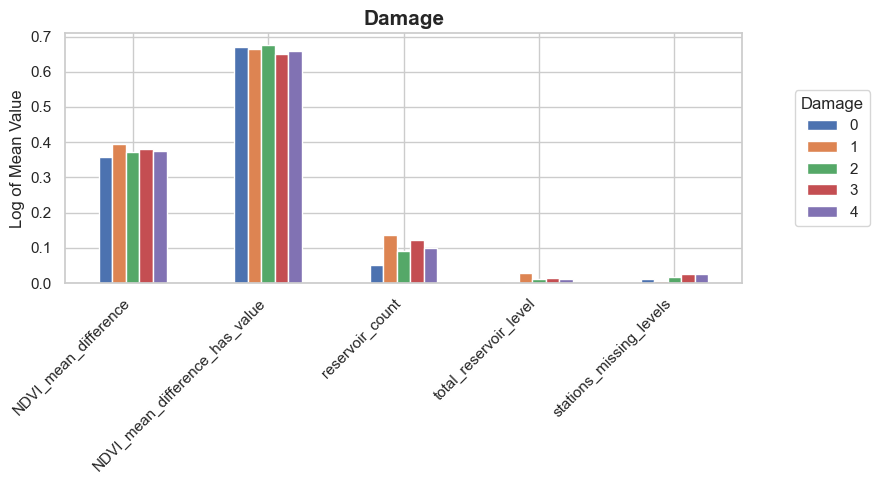

In [20]:
plot_all(X[feature_sets['Others']], target_ignition, target_spread,target_damage,'Wind Slope Interactions')

## 8. Export File

In [21]:
print("All datasets saved successfully to ../data/processed/")

All datasets saved successfully to ../data/processed/


In [58]:
ignition_xgb_top10 = pd.read_csv('../data/processed/ignition_xgb_top10.csv')
ignition_rf_top10 = pd.read_csv('../data/processed/ignition_rf_top10.csv')
spread_xgb_top10 = pd.read_csv('../data/processed/spread_xgb_top10.csv')
spread_rf_top10 = pd.read_csv('../data/processed/spread_rf_top10.csv')
damage_xgb_top10 = pd.read_csv('../data/processed/damage_xgb_top10.csv')
damage_rf_top10 = pd.read_csv('../data/processed/damage_rf_top10.csv')

In [59]:
spread_xgb_top10 = spread_xgb_top10.drop(spread_xgb_top10.index[4])

## Ignition Top 5

In [61]:
ignition_xgb_top5 = list(ignition_xgb_top10.loc[0:5,'0'].values)
ignition_rf_top5 = list(ignition_rf_top10.loc[0:5,'0'].values)
spread_xgb_top5 = list(spread_xgb_top10.loc[0:5,'0'].values)
spread_rf_top5 = list(spread_rf_top10.loc[0:5,'0'].values)
damage_xgb_top5 = list(damage_xgb_top10.loc[0:5,'0'].values)
damage_rf_top5 = list(damage_rf_top10.loc[0:5,'0'].values)

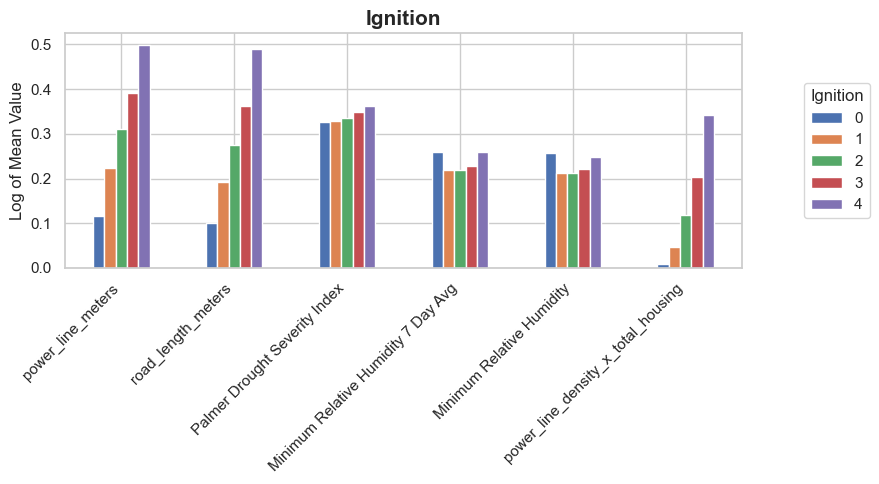

In [62]:
bar_group(X[ignition_xgb_top5], target_ignition,'Ignition')

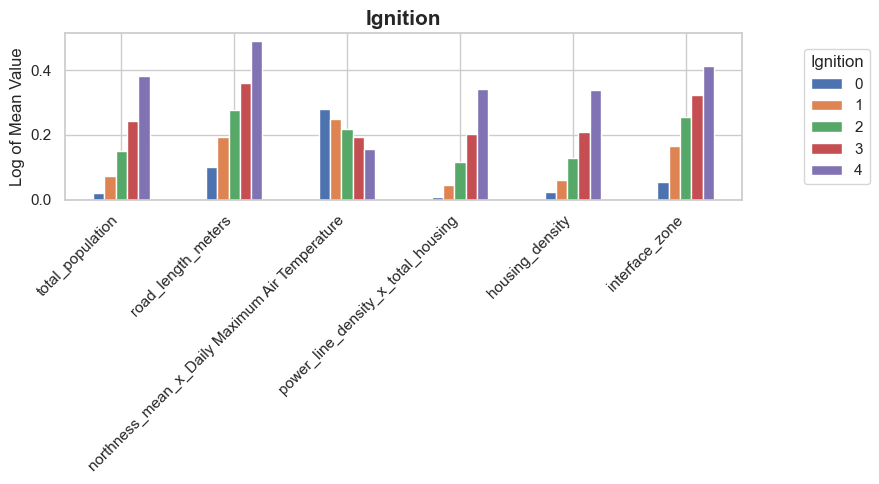

In [63]:
bar_group(X[ignition_rf_top5], target_ignition,'Ignition')

## Spread Top 5

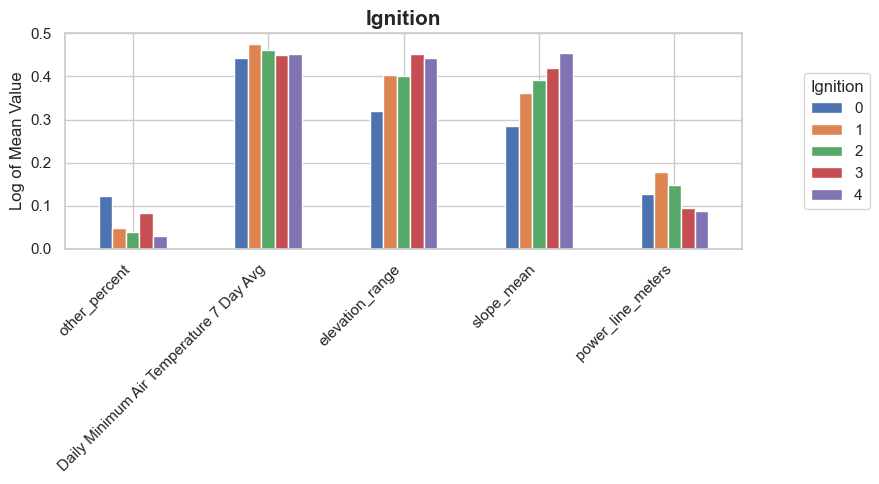

In [64]:
bar_group(X[spread_xgb_top5], target_spread,'Ignition')

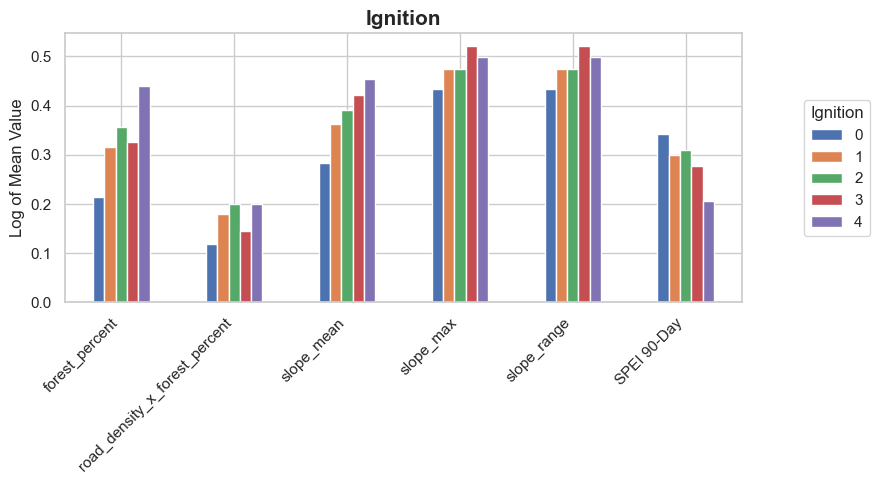

In [65]:
bar_group(X[spread_rf_top5], target_spread,'Ignition')

## Damage Top 5

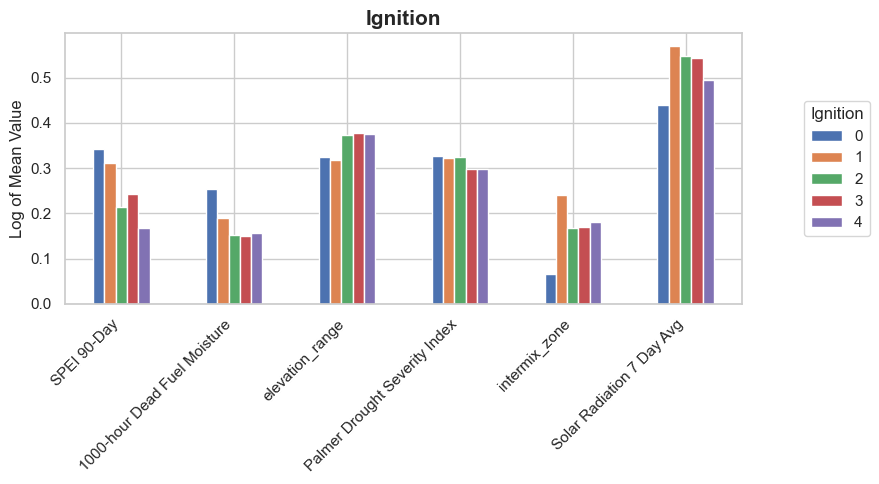

In [66]:
bar_group(X[damage_xgb_top5], target_damage,'Ignition')

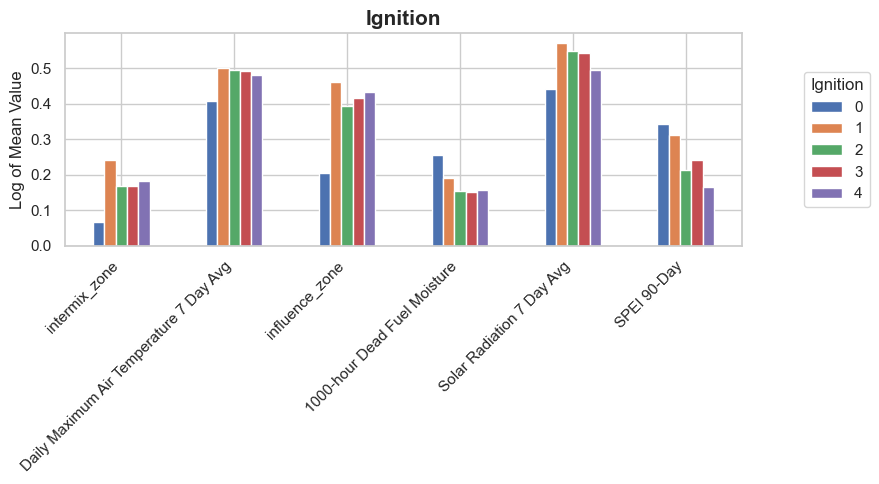

In [67]:
bar_group(X[damage_rf_top5], target_damage,'Ignition')